In [1]:
from shapely.geometry import shape, mapping

aoi = shape({'type': 'Polygon',
 'coordinates': (((9.793244572339118, 28.078809211916575),
   (9.79337728000809, 28.096861838476748),
   (9.77301972548242, 28.09697806509998),
   (9.772890422170368, 28.07892535081824),
   (9.793244572339118, 28.078809211916575)),)})

In [2]:
from georeader.readers import tileserver

output = tileserver.read_from_tileserver("https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}", aoi, 
                         zoom=16, crs_geometry="EPSG:4326")
output

 
         Transform: | 2.39, 0.00, 1087911.50|
| 0.00,-2.39, 3261207.31|
| 0.00, 0.00, 1.00|
         Shape: (3, 961, 956)
         Resolution: (2.388657134026289, 2.388657134026289)
         Bounds: (1087911.502982975, 3258911.81019556, 1090195.0592029945, 3261207.3097012495)
         CRS: EPSG:3857
         fill_value_default: 0
        

<Axes: >

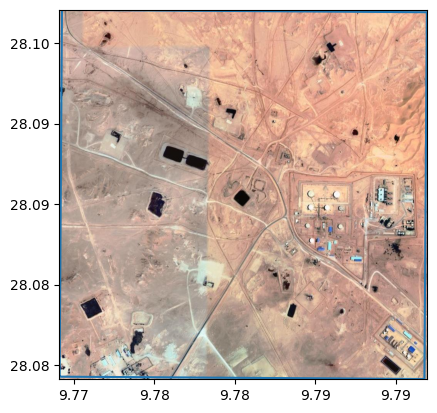

In [3]:
from georeader import plot

ax = plot.show(output)
plot.add_shape_to_plot(aoi, crs_plot=output.crs, crs_shape="EPSG:4326", polygon_no_fill=True)

## Async alternative — `AsyncGeoTIFFReader` against a public COG

The tile-server example above reads stitched XYZ tiles via HTTP (the
common tile-server protocol). For COG sources — files written once and
served with HTTP range requests — `AsyncGeoTIFFReader` is the better
shape: same metadata surface as `RasterioReader`, but reads are coroutines
you can fan out with `asyncio.gather`.

The two protocols are different (XYZ tiles ≠ COG windows), so this is
**not a 1:1 swap on the same input**. The cell below demonstrates the
equivalent shape against a real public COG — a Sentinel-2 L2A scene from
[Element 84's `sentinel-cogs` bucket](https://registry.opendata.aws/sentinel-2-l2a-cogs/)
(anonymously readable on AWS).

Needs: `pip install georeader-spaceml[async] obstore`


In [4]:
import asyncio

import rasterio.windows
from obstore.store import S3Store

from georeader.async_geotiff_reader import AsyncGeoTIFFReader

# Element 84's sentinel-cogs bucket is anonymously readable on AWS.
store = S3Store(bucket="sentinel-cogs", region="us-west-2", skip_signature=True)

# A stable public S2 L2A scene (UTM zone 30, MGRS tile T-UM, May 2022).
scene_path = (
    "sentinel-s2-l2a-cogs/30/T/UM/2022/5/S2A_30TUM_20220506_0_L2A/B04.tif"
)

# open() fetches only the COG header (cheap; small range request).
reader = await AsyncGeoTIFFReader.open(scene_path, store=store)
print(f"CRS:       {reader.crs}")
print(f"shape:     {reader.shape}")
print(f"dtype:     {reader.dtype}")
print(f"overviews: {len(reader._geotiff.overviews)}")


CRS:       EPSG:32630
shape:     (1, 10980, 10980)
dtype:     uint16
overviews: 4


In [5]:
# Fan out 16 concurrent window reads from one process / one event loop /
# one S3Store. Each await is a coroutine; asyncio.gather schedules them
# all at once, the Rust core coalesces adjacent tile fetches inside each call.
windows = [
    rasterio.windows.Window(col_off=5000 + (i % 4) * 256,
                            row_off=5000 + (i // 4) * 256,
                            width=256, height=256)
    for i in range(16)
]

chips = await asyncio.gather(*[reader.read_from_window(w) for w in windows])

print(f"Issued {len(windows)} concurrent reads from one process")
print(f"All shapes correct: {all(c.values.shape == (1, 256, 256) for c in chips)}")


Issued 16 concurrent reads from one process
All shapes correct: True


See [`docs/advanced/async_geotiff_reader.ipynb`](../docs/advanced/async_geotiff_reader.ipynb)
for the full tutorial — the two-phase laziness model, overviews, the
post-load warp mini-solution, and the gotchas (TIFF/COG only, no warp,
not pickleable across processes).


## Licence
The georeader package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)

 If you find this work useful please cite:

```
@article{ruzicka_starcop_2023,
	title = {Semantic segmentation of methane plumes with hyperspectral machine learning models},
	volume = {13},
	issn = {2045-2322},
	url = {https://www.nature.com/articles/s41598-023-44918-6},
	doi = {10.1038/s41598-023-44918-6},
	number = {1},
	journal = {Scientific Reports},
	author = {Růžička, Vít and Mateo-Garcia, Gonzalo and Gómez-Chova, Luis and Vaughan, Anna, and Guanter, Luis and Markham, Andrew},
	month = nov,
	year = {2023},
	pages = {19999},
}
```